<a href="https://colab.research.google.com/github/Bica-plus-equals/Titanic-Logistic-Regression/blob/main/LogisticRegression_Project1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Titanic Survival Predictions

Predict passenger survival using *logistic regression*. The notebook focuses on *feature engineering and validation* best practices, leading to an analysis on **the accuracy potential of logistic models on real-life datasets**.

### 1. Loading Data


In [ ]:
#Imports
import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

import seaborn as sns

sns.set_theme(style='whitegrid')

In [ ]:
# Kaggle downloads
path = kagglehub.dataset_download("shuofxz/titanic-machine-learning-from-disaster")
content = os.listdir(path)
print(content)

Using Colab cache for faster access to the 'titanic-machine-learning-from-disaster' dataset.
['train.csv', 'test.csv']


In [ ]:
#Load train/test data
train_data = pd.read_csv(os.path.join(path, 'train.csv'))
test_data = pd.read_csv(os.path.join(path, 'test.csv'))

print(train_data.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


### 2. Data Investigation

In [ ]:
#Check nb of features and samples
print(train_data.shape)

#Get index dtype and columns, non-NA values and memory usage
print('*'*30)
train_data.info()

#Count null-values
print('*'*30)
print('Number of null samples per feature')
train_data.isnull().sum() #it summs all the 'True' instances


(891, 12)
******************************
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
******************************
Number of null samples per feature


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


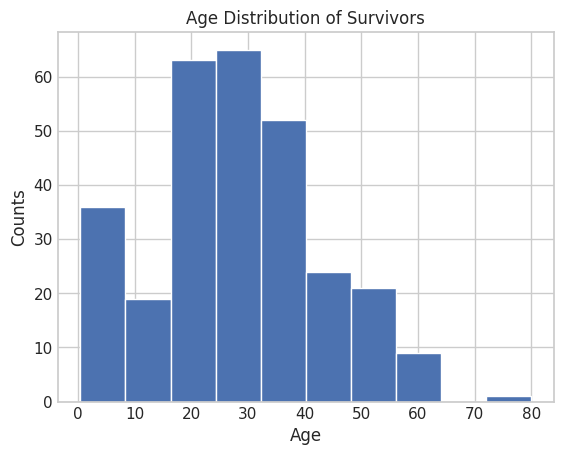

In [ ]:
#Plot some distributions of survivors to identify patterns

survived_list = train_data[train_data['Survived'] == 1]

survived_list['Age'].plot(kind='hist')
plt.title('Age Distribution of Survivors')
plt.xlabel('Age')
plt.ylabel('Counts')
plt.tick_params(direction='in')

In [ ]:
#See how many labels of each class there are
train_data['Survived'].value_counts()

,count
Survived,
0,549
1,342


### 3. Cleaning Data

Remove Cabin column - 712 remaining data points


In [ ]:
train_data = train_data.drop(['Cabin'], axis=1)
test_data = test_data.drop(['Cabin'], axis=1)

#Drop all non-full entries
train_data = train_data.dropna(axis=0) #712 remaining data points
test_data = test_data.dropna(axis=0) # 331 remaining data points

# print(train_data.info())
# print(test_data.info())

KeyError: "['Cabin'] not found in axis"

### 4. Feature Engineering

Name : the 'name' data is often a long, unique-valued string. We extract the useful signals such as the titles: Mr, Miss, Mrs, Master. Unusual titles are mapped onto these values based on gender.

In [ ]:
df = train_data

In [ ]:
#Extract titles and drop name data
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.')
df = df.drop(['Name'], axis=1)

#Map titles onto a few groups: common titles + rare
common_titles = ['Mr', 'Miss', 'Mrs', 'Master']

df['Title'] = df['Title'].apply(lambda x: 'Rare' if x not in common_titles else x)

#Show counts of each
df['Title'].value_counts()


<>:2: SyntaxWarning: invalid escape sequence '\.'
<>:2: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_9722/661298405.py:2: SyntaxWarning: invalid escape sequence '\.'
  df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.')


,count
Title,
Mr,398
Miss,145
Mrs,107
Master,36
Rare,26


In [ ]:
#One-hot encoding
df = pd.get_dummies(df, columns=['Title'])

Encode gender and keep only one variable

In [ ]:
#Encode gender, drop one of them
df = pd.get_dummies(df, columns=['Sex'],drop_first=True)


Create 'Family_members' variable by combining 'SibSp' (number of siblings/spouses) and 'Parch' (number of parents/children) to get a stronger signal of relatedness.

In [ ]:
#SibSp and Parch
df['Family_members'] = df['SibSp'] + df['Parch']
df = df.drop(['SibSp', 'Parch'], axis=1)


Extract signal from 'Ticket' data showing the number of times the same ticket was used (ie groups travelling together).

In [ ]:
ticket_counts = df['Ticket'].value_counts()

df['TicketGroupSize'] = df['Ticket'].map(ticket_counts)

df.drop(['Ticket'], axis=1, inplace=True)


Drop passenger id (useless data)

In [ ]:
df.drop(['PassengerId'], axis=1, inplace=True)
df.columns

Index(['Survived', 'Pclass', 'Age', 'Fare', 'Embarked', 'Age2', 'Title_Master',
       'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare', 'Sex_male',
       'Family_members', 'TicketGroupSize'],
      dtype='object')

Encode 'Embarked' data and show final features

In [ ]:
df = pd.get_dummies(df, columns=['Embarked'])

In [ ]:
df.columns

Index(['Survived', 'Pclass', 'Age', 'Fare', 'Age2', 'Title_Master',
       'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare', 'Sex_male',
       'Family_members', 'TicketGroupSize', 'Embarked_C', 'Embarked_Q',
       'Embarked_S'],
      dtype='object')

###5. Model Training: Logistic Regression

Baseline

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

y = df['Survived']
X = df.drop(['Survived'], axis=1)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42)

logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train, y_train)

predictions = logistic_model.predict(X_val)

accuracy = accuracy_score(y_val, predictions)
print("Accuracy:", accuracy)

#or use: logistic_model.score(X_val, y_val)

Accuracy: 0.8111888111888111


####5.1. Model Fine-tuning: significant

#####Experiment #1: Regulatization parameter C

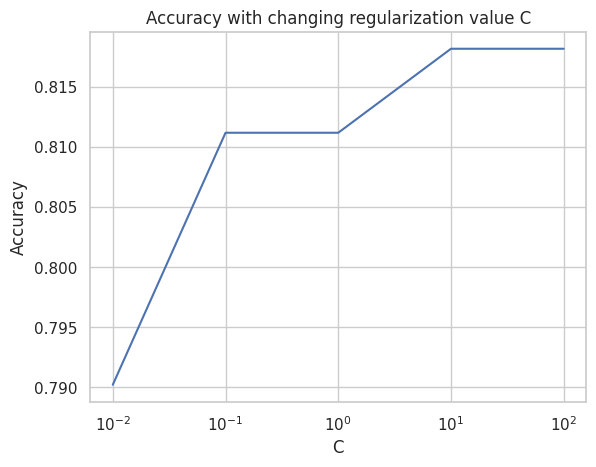

In [ ]:
C_vals = [0.01, 0.1, 1, 10, 100,100]

accuracy_res = []

for C in C_vals:
  logistic_model = LogisticRegression(max_iter=1000, C = C)

  logistic_model.fit(X_train, y_train)

  predictions = logistic_model.predict(X_val)

  accuracy = accuracy_score(y_val, predictions)

  accuracy_res.append(accuracy)

plt.title('Accuracy with changing regularization value C')
plt.plot(C_vals, accuracy_res)
plt.xscale('log')
plt.xlabel('C')
plt.ylabel('Accuracy')
plt.show()

#####Experiment#2 : Elastic-net L1_ratio

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


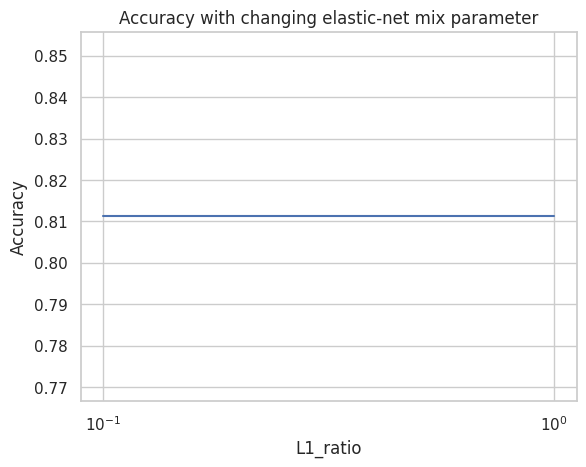

In [ ]:
l1_vals = [0.1, 0.2, 0.5, 1]

accuracy_res = []

for l1 in l1_vals:

  logistic_model = LogisticRegression(max_iter=1000, l1_ratio=l1)

  logistic_model.fit(X_train, y_train)

  predictions = logistic_model.predict(X_val)

  accuracy = accuracy_score(y_val, predictions)

  accuracy_res.append(accuracy)

plt.plot(l1_vals, accuracy_res)
plt.title('Accuracy with changing elastic-net mix parameter')
plt.xscale('log')
plt.xlabel('L1_ratio')
plt.ylabel('Accuracy')
plt.show()

#####Experiment#3: Solver settings

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


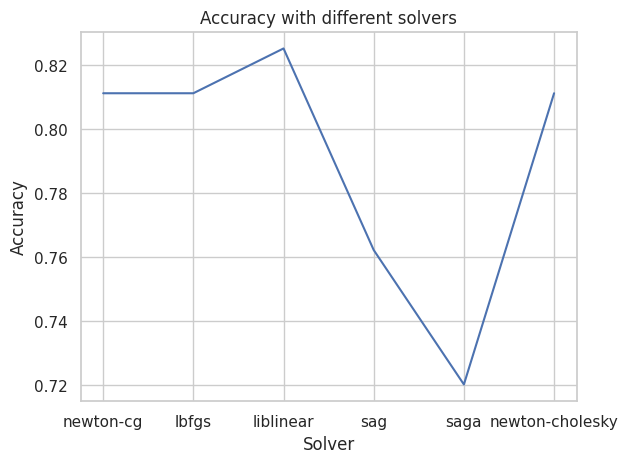

In [ ]:
solvers = ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga', 'newton-cholesky']

accuracy_res = []

for solver in solvers:
  logistic_model = LogisticRegression(max_iter=1000, solver=solver)
  logistic_model.fit(X_train, y_train)
  predictions = logistic_model.predict(X_val)
  accuracy = accuracy_score(y_val, predictions)
  accuracy_res.append(accuracy)

plt.plot(solvers, accuracy_res)
plt.title('Accuracy with different solvers')
plt.xlabel('Solver')
plt.ylabel('Accuracy')
plt.show()

liblinear is better +1%

#####Experiment#4: Nb of iterations

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


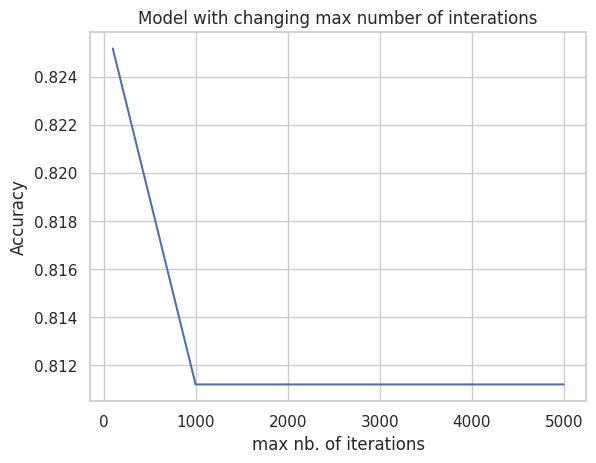

In [ ]:
max_iter_vals = [100, 1000, 5000]

accuracy_res = []

for max_iter in max_iter_vals:
  logistic_model = LogisticRegression(max_iter=max_iter)
  logistic_model.fit(X_train, y_train)
  predictions = logistic_model.predict(X_val)
  accuracy = accuracy_score(y_val, predictions)
  accuracy_res.append(accuracy)

plt.plot(max_iter_vals, accuracy_res)
plt.title('Model with changing max number of interations')
plt.xlabel('max nb. of iterations')
plt.ylabel('Accuracy')
plt.show()

####5.2. Feature improvements: no effect

#####Fewer Male signifiers: Exact same result

In [ ]:
#Reducing male features
newdf = df.copy()

newdf = newdf.drop(['Title_Master' ,'Title_Miss', 'Title_Mr', 'Title_Mrs',
 'Title_Rare'], axis=1)

In [ ]:
y = newdf['Survived']
X = newdf.drop(['Survived'], axis=1)

logistic_model1 = LogisticRegression(max_iter=1000)

X_train, X_val, y_train, y_val = train_test_split(
  X, y,  test_size=0.2, random_state=42)

logistic_model1.fit(X_train, y_train)

print(logistic_model1.score(X_val, y_val))

0.8111888111888111


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


**Note:** Exact same results, regardless of reducing male features to only one.

#####Handling continous data: polynomials, normalization and binning made it worse or did nothing

Using Age-squared to improve linear signal: no improvements

In [ ]:
newdf = df.copy()

newdf['Age2'] = newdf['Age'] ** 2
newdf = newdf.drop(['Age'], axis=1)

X = newdf.drop(['Survived'], axis=1)
y = newdf['Survived']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size = 0.2, random_state=42)

logistic_model2 = LogisticRegression(max_iter=1000)

logistic_model2.fit(X_train, y_train)

print(logistic_model2.score(X_val, y_val))

0.8111888111888111


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Normalization: no improvement

In [ ]:
from sklearn.preprocessing import StandardScaler

newdf = df.copy()

scaler = StandardScaler()

X = newdf.drop(['Survived'], axis=1)
y = newdf['Survived']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size = 0.2, random_state=42)

X_train[['Age','Fare']] = scaler.fit_transform(X_train[['Age','Fare']])
X_val[['Age','Fare']] = scaler.transform(X_val[['Age','Fare']])

logistic_model3 = LogisticRegression(max_iter=1000)

logistic_model3.fit(X_train, y_train)

print(logistic_model3.score(X_val, y_val))

0.8111888111888111


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Categorizing / Binning: nothing

In [ ]:
newdf = df.copy()

newdf['AgeGroup'] = pd.cut(newdf['Age'], bins=[0,20,50,100])
newdf = pd.get_dummies(newdf, columns=['AgeGroup'])
newdf = newdf.drop(['Age'], axis=1)

In [ ]:
y = newdf['Survived']
X = newdf.drop(['Survived'], axis=1)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

logistic_model4 = LogisticRegression(max_iter=1000)

logistic_model4.fit(X_train, y_train)

print(logistic_model4.score(X_val, y_val))

0.8111888111888111


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


#####Log-transform fare -  it has a skewed distribution so it might help learning since it will make it more uniform

In [ ]:
newdf = df.copy()

newdf['Fare_log'] = np.log1p(newdf['Fare'])
newdf = newdf.drop(['Fare'], axis=1)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

logistic_model5 = LogisticRegression(max_iter=1000)

logistic_model5.fit(X_train, y_train)

print(logistic_model5.score(X_val, y_val))


0.8111888111888111


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


again, absolutely nothing changed

#####Add 'Alone' parameter

In [ ]:
newdf = df.copy()

newdf['Alone'] = (newdf['Family_members'] == 0).astype(int)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

logistic_model6 = LogisticRegression(max_iter=1000)

logistic_model6.fit(X_train, y_train)

print(logistic_model6.score(X_val, y_val))

0.8111888111888111


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


exactly the same

###6. Validation

In [ ]:
y = df['Survived']
X = df.drop(['Survived'], axis=1)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42)

logistic_model = LogisticRegression(C=50, solver='liblinear',max_iter=2000,)

logistic_model.fit(X_train, y_train)

predictions = logistic_model.predict(X_val)

accuracy = accuracy_score(y_val, predictions)
print("Accuracy:", accuracy)

Accuracy: 0.8181818181818182


Cross-validation

In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(logistic_model, X, y, cv=5)

print(scores)
print(scores.mean())
print(scores.std())

[0.78321678 0.84615385 0.78873239 0.8028169  0.87323944]
0.818831872352999
0.03503588373489287


oh wow, this is interesting. there is quite a variation! the std is like 2.85%. Data is small enough that sampling matters.So the model is not very 'stable', it will give different results based on the train/test split chosen.

Stratified K-fold

In [ ]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(logistic_model, X, y, cv=cv)

print(scores)
print(scores.mean())
print(scores.std())

[0.87412587 0.83216783 0.79577465 0.78169014 0.85211268]
0.8271742342164877
0.03436875081681722


I mean...the model performance is better, but the std is still quite high.

LOOCV (bc the dataset is small)

In [ ]:
from sklearn.model_selection import LeaveOneOut

loo = LeaveOneOut()

scores = cross_val_score(logistic_model, X, y, cv=loo)

#print(scores)
print(scores.mean())
print(scores.std())

0.8230337078651685
0.38164017553564894


std even higher

###7. Results & Discussion


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, predictions)
print(cm)

[[70 10]
 [16 47]]


70 - true negatives; 46 - true positives
10 - false positives 17 - false negatives

In [ ]:
#Classification Report
from sklearn.metrics import classification_report

print(classification_report(y_val, predictions))

              precision    recall  f1-score   support

           0       0.81      0.88      0.84        80
           1       0.82      0.75      0.78        63

    accuracy                           0.82       143
   macro avg       0.82      0.81      0.81       143
weighted avg       0.82      0.82      0.82       143



you can tell that the unevenly balanced data between survived/not-survived has influenced the model. Since there are more examples of non-survivors, the model performs better on the negative samples. Should there be more positive data, or at least an equal amount, the predictions could be improved. (test that)

In [ ]:
#ROC-AUC (using predicted probabilities, not absolute values)
#look more into this

from sklearn.metrics import roc_auc_score

probs = logistic_model.predict_proba(X_val)[:,1]

score = roc_auc_score(y_val, probs)

print('ROC-AUC:',score)

ROC-AUC: 0.8398809523809525


In [ ]:
#Inspect model attributes
print('Feature Names:', logistic_model.feature_names_in_)
print('Coefficients:',logistic_model.coef_)
print('Classes ndarray:',logistic_model.classes_)
print('Intercept :', logistic_model.intercept_)
print('Nb of features see:', logistic_model.n_features_in_)
print('Nb of iterations for all classes:', logistic_model.n_iter_)

coefs_dict = {'Feature': logistic_model.feature_names_in_,
                        'Coefficient': logistic_model.coef_[0]}
coefs_df = pd.DataFrame(coefs_dict)

print(coefs_df.sort_values(by='Coefficient', ascending=True))

Feature Names: ['Pclass' 'Age' 'Fare' 'Age2' 'Title_Master' 'Title_Miss' 'Title_Mr'
 'Title_Mrs' 'Title_Rare' 'Sex_male' 'Family_members' 'TicketGroupSize'
 'Embarked_C' 'Embarked_Q' 'Embarked_S']
Coefficients: [[-1.27328884e+00 -5.89830991e-02  3.23428564e-03  3.60810656e-04
   2.46135073e+00  4.35604312e-01 -5.60923394e-01  1.68064926e+00
  -2.25795992e-02 -1.87236663e+00 -1.67726524e-01 -4.14672245e-01
   1.63945405e+00  9.85522367e-01  1.36912489e+00]]
Classes ndarray: [0 1]
Intercept : [3.9941013]
Nb of features see: 15
Nb of iterations for all classes: [25]
            Feature  Coefficient
9          Sex_male    -1.872367
0            Pclass    -1.273289
6          Title_Mr    -0.560923
11  TicketGroupSize    -0.414672
10   Family_members    -0.167727
1               Age    -0.058983
8        Title_Rare    -0.022580
3              Age2     0.000361
2              Fare     0.003234
5        Title_Miss     0.435604
13       Embarked_Q     0.985522
14       Embarked_S     1.369125
1

The coefficients show strong negative bias towards male genders (reflected in both Sex_male and Title_Mr strong negative coefficientsS), and surprisingly Class number! Slightly more moderate negatives are seen in rare titles which are often male or less protected. Surprisingly, larger groups are harder to evacuate (hence ticekt group size is also slightly negative), and people who embarket at queenstown often from socioeconomic groups are also slightly disadvntages.

The model fails to assign a proper weight to age and fare data, arguably the two most important datapoints. That is because the logistic regression model fails to capture non-linear patterns in continous data. -> task

Strong positives are seen in male children (title master ~ 1.36), adult women, and people who embarked in C.

Oh, notice there are scale differences! The fares should be normalised before to avoid this weight problem! since the values are large, the weights are kept small, but this doesnt signify lack of importance. Realistically, this wouldnt matter in the model calculations, but normalising values makes for an easier comparison. -> task

Also note that because there are essentially 4-5 male-signaling features in the dataset, the weights are distributed onto them, instead of concentrated into one 'Male' feature.  -> task

Notice the presence of a intercept term. Given that there are 4 male-signaling negative terms, the intercept balances that (and other contributions) with a value at 5,26.

Logistic regression model is:
log-odds=w1​x1​+w2​x2​+⋯+b

###8. Comparison Models

Decision Tree


In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier

dtree_model = DecisionTreeClassifier(random_state=42)

dtree_model.fit(X_train, y_train)

predictions = dtree_model.predict(X_val)

accuracy = accuracy_score(y_val, predictions)
print('Accuracy:',accuracy)

Accuracy: 0.7552447552447552


Random Forest



In [ ]:
from sklearn.ensemble import RandomForestClassifier

rforest_model = RandomForestClassifier(n_estimators=80, random_state=42, max_depth=20)

rforest_model.fit(X_train, y_train)

predictions = rforest_model.predict(X_val)

accuracy = accuracy_score(y_val, predictions)

print('Accuracy:',accuracy)



Accuracy: 0.7412587412587412
